# Part 2, Notebook 2: Classification data and augmentation

Notebook 1 studied the data. Here we turn it into model-ready inputs.

By the end, you will be able to explain cropping, train-only augmentation, PyTorch Dataset and DataLoader objects, batch shapes, and ImageNet normalization.

> This notebook prepares data only. It does not train or evaluate a model.

In [1]:
# Imports make reusable classes and functions available.
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from IPython.display import display
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA ready:  {torch.cuda.is_available()} (CPU is expected on this laptop)")

PyTorch:     2.13.0+cpu
Torchvision: 0.28.0+cpu
CUDA ready:  False (CPU is expected on this laptop)


## 1. Locate the data

A Path represents a file or folder location. The slash operator joins path pieces safely on Windows. Downloaded data and generated crops are ignored by Git because they are large and reproducible.

In [2]:
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / "pyproject.toml").exists() else CURRENT_FOLDER.parent
DATASET_ROOT = PROJECT_ROOT / "data" / "oxford-iiit-pet"
IMAGES_DIR = DATASET_ROOT / "images"
ANNOTATIONS_DIR = DATASET_ROOT / "annotations"
MASKS_DIR = ANNOTATIONS_DIR / "trimaps"
CROPS_ROOT = PROJECT_ROOT / "data" / "classification_crops"
METADATA_PATH = CROPS_ROOT / "metadata.csv"

required_paths = [IMAGES_DIR, MASKS_DIR, ANNOTATIONS_DIR / "trainval.txt", ANNOTATIONS_DIR / "test.txt"]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = "\n".join(f"  - {path}" for path in missing_paths)
    raise FileNotFoundError(
        f"Missing required dataset paths:\n{formatted}\n\n"
        "Run this in the VS Code terminal from the project root:\n"
        "  uv run python scripts/download_learning_dataset.py"
    )

CROPS_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Crops folder: {CROPS_ROOT}")
print("Preflight check passed.")

Project root: D:\Projects\parrot-detector
Crops folder: D:\Projects\parrot-detector\data\classification_crops
Preflight check passed.


## 2. Reproduce the same records

We reuse seed 42, the same classes, and the invalid-mask check from Notebook 1. Rerunning this recipe therefore gives the same split membership.

Validation comes from official training data. Official test records remain separate and will not guide our choices.

In [3]:
SELECTED_CLASSES = ("Abyssinian", "Bengal", "Egyptian Mau")
CLASS_TO_ID = {name: class_id for class_id, name in enumerate(SELECTED_CLASSES)}

def read_official_split(split_name: str) -> pd.DataFrame:
    """Read one official annotation file into a table."""
    rows = []
    split_file = ANNOTATIONS_DIR / f"{split_name}.txt"
    for line_number, line in enumerate(split_file.read_text().splitlines(), start=1):
        parts = line.split()
        if len(parts) != 4:
            raise ValueError(f"{split_file}:{line_number} expected 4 values")
        image_id = parts[0]
        class_name = image_id.rsplit("_", 1)[0].replace("_", " ").title()
        rows.append({
            "official_split": split_name,
            "image_id": image_id,
            "class_name": class_name,
            "source_image_path": IMAGES_DIR / f"{image_id}.jpg",
            "mask_path": MASKS_DIR / f"{image_id}.png",
        })
    return pd.DataFrame(rows)

def mask_to_box(mask_path: Path) -> tuple[int, int, int, int]:
    """Return a tight, half-open (x1, y1, x2, y2) animal box."""
    with Image.open(mask_path) as mask_image:
        mask = np.asarray(mask_image)
    y_coordinates, x_coordinates = np.where(mask != 2)
    if len(x_coordinates) == 0:
        raise ValueError(f"Mask has no animal pixels: {mask_path}")
    return (
        int(x_coordinates.min()), int(y_coordinates.min()),
        int(x_coordinates.max()) + 1, int(y_coordinates.max()) + 1,
    )

In [4]:
official_trainval = read_official_split("trainval")
official_test = read_official_split("test")
selected_trainval = official_trainval[official_trainval["class_name"].isin(SELECTED_CLASSES)].copy()
selected_test = official_test[official_test["class_name"].isin(SELECTED_CLASSES)].copy()

candidates = pd.concat([selected_trainval, selected_test], ignore_index=True)
invalid_mask_ids = []
for row in tqdm(candidates.itertuples(index=False), total=len(candidates), desc="Validating masks"):
    with Image.open(row.mask_path) as mask_image:
        mask = np.asarray(mask_image)
    if not np.any(mask != 2):
        invalid_mask_ids.append(row.image_id)

selected_trainval = selected_trainval[~selected_trainval["image_id"].isin(invalid_mask_ids)].copy()
selected_test = selected_test[~selected_test["image_id"].isin(invalid_mask_ids)].copy()
train_rows, val_rows = train_test_split(
    selected_trainval, test_size=0.20, random_state=RANDOM_SEED,
    stratify=selected_trainval["class_name"],
)

parts = []
for split_name, frame in (("train", train_rows), ("val", val_rows), ("test", selected_test)):
    part = frame.copy()
    part["split"] = split_name
    parts.append(part)
records = pd.concat(parts, ignore_index=True)
records["label_id"] = records["class_name"].map(CLASS_TO_ID)
records = records.sort_values(["split", "class_name", "image_id"]).reset_index(drop=True)

split_sets = {name: set(group["image_id"]) for name, group in records.groupby("split")}
assert split_sets["train"].isdisjoint(split_sets["val"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["val"].isdisjoint(split_sets["test"])
assert len(records) == 584, f"Expected 584 valid records, found {len(records)}"

print(f"Excluded invalid masks: {invalid_mask_ids}")
display(records.pivot_table(index="split", columns="class_name", values="image_id", aggfunc="count"))

Validating masks:   0%|          | 0/588 [00:00<?, ?it/s]

Excluded invalid masks: ['Egyptian_Mau_162', 'Egyptian_Mau_165', 'Egyptian_Mau_196', 'Egyptian_Mau_20']


class_name,Abyssinian,Bengal,Egyptian Mau
split,,,
test,98,100,96
train,80,80,72
val,20,20,18


## 3. Save classification crops

PIL crops use (left, top, right, bottom). The right and bottom edges are exclusive, so mask_to_box adds one to each maximum coordinate.

Each crop has one class label. Cropping reduces background shortcuts, although the rectangle can still contain background. This cell is safe to rerun: the same names receive the same deterministic crops.

In [5]:
metadata_rows = []
for row in tqdm(records.itertuples(index=False), total=len(records), desc="Saving crops"):
    x1, y1, x2, y2 = mask_to_box(row.mask_path)
    class_folder = row.class_name.replace(" ", "_")
    crop_path = CROPS_ROOT / row.split / class_folder / f"{row.image_id}.jpg"
    crop_path.parent.mkdir(parents=True, exist_ok=True)

    with Image.open(row.source_image_path) as source_image:
        crop = source_image.convert("RGB").crop((x1, y1, x2, y2))
        crop.save(crop_path, quality=95)

    metadata_rows.append({
        "image_id": row.image_id,
        "split": row.split,
        "class_name": row.class_name,
        "label_id": row.label_id,
        "source_image_path": row.source_image_path.relative_to(PROJECT_ROOT).as_posix(),
        "mask_path": row.mask_path.relative_to(PROJECT_ROOT).as_posix(),
        "crop_path": crop_path.relative_to(PROJECT_ROOT).as_posix(),
        "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        "crop_width": x2 - x1, "crop_height": y2 - y1,
    })

metadata = pd.DataFrame(metadata_rows)
metadata.to_csv(METADATA_PATH, index=False)
print(f"Saved {len(metadata):,} crops and metadata to {METADATA_PATH}")
display(metadata.head())

Saving crops:   0%|          | 0/584 [00:00<?, ?it/s]

Saved 584 crops and metadata to D:\Projects\parrot-detector\data\classification_crops\metadata.csv


,image_id,split,class_name,label_id,source_image_path,mask_path,crop_path,x1,y1,x2,y2,crop_width,crop_height
0,Abyssinian_2,test,Abyssinian,0,data/oxford-iiit-pet/images/Abyssinian_2.jpg,data/oxford-iiit-pet/annotations/trimaps/Abyss...,data/classification_crops/test/Abyssinian/Abys...,109,4,579,473,470,469
1,Abyssinian_20,test,Abyssinian,0,data/oxford-iiit-pet/images/Abyssinian_20.jpg,data/oxford-iiit-pet/annotations/trimaps/Abyss...,data/classification_crops/test/Abyssinian/Abys...,154,29,330,376,176,347
2,Abyssinian_201,test,Abyssinian,0,data/oxford-iiit-pet/images/Abyssinian_201.jpg,data/oxford-iiit-pet/annotations/trimaps/Abyss...,data/classification_crops/test/Abyssinian/Abys...,89,81,300,225,211,144
3,Abyssinian_202,test,Abyssinian,0,data/oxford-iiit-pet/images/Abyssinian_202.jpg,data/oxford-iiit-pet/annotations/trimaps/Abyss...,data/classification_crops/test/Abyssinian/Abys...,102,12,238,209,136,197
4,Abyssinian_204,test,Abyssinian,0,data/oxford-iiit-pet/images/Abyssinian_204.jpg,data/oxford-iiit-pet/annotations/trimaps/Abyss...,data/classification_crops/test/Abyssinian/Abys...,7,34,202,300,195,266


In [6]:
# Assertions are data tests: they stop if an assumption is false.
assert len(metadata) == 584
assert not metadata["image_id"].duplicated().any()
assert metadata["crop_path"].map(lambda value: (PROJECT_ROOT / value).exists()).all()
assert (metadata["crop_width"] > 0).all() and (metadata["crop_height"] > 0).all()
assert set(metadata["label_id"]) == {0, 1, 2}

display(metadata.pivot_table(
    index="split", columns="class_name", values="image_id", aggfunc="count"
))
print("Crop integrity checks passed.")

class_name,Abyssinian,Bengal,Egyptian Mau
split,,,
test,98,100,96
train,80,80,72
val,20,20,18


Crop integrity checks passed.


## 4. Define transforms and augmentation

A transform changes an image before the model sees it. Every split is resized to 224 by 224 and converted to a tensor.

Training also gets random horizontal flips, small rotations, and mild colour changes. These teach useful tolerance without changing the breed. Validation and test remain deterministic so their scores are stable.

We use ImageNet mean and standard deviation because Notebook 3 will use a ResNet18 pretrained on ImageNet.

In [7]:
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Training transform includes randomness.")
print("Validation/test transform is deterministic.")

Training transform includes randomness.
Validation/test transform is deterministic.


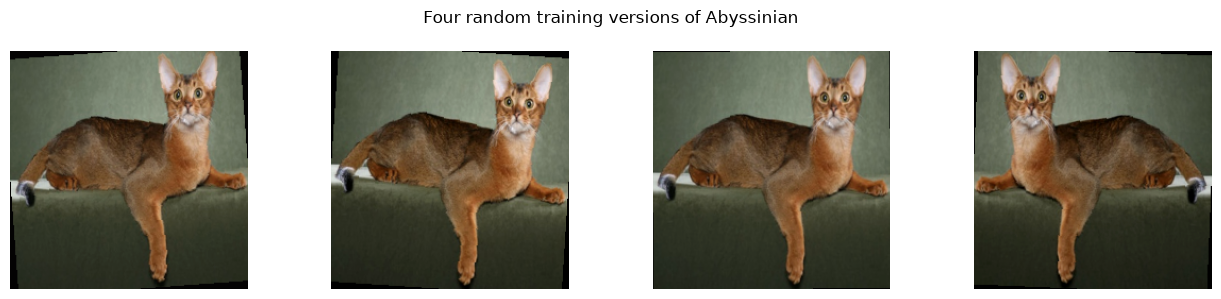

In [8]:
# Undo normalization only so Matplotlib can display ordinary colours.
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def tensor_for_display(tensor: torch.Tensor) -> np.ndarray:
    image = (tensor.cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

example_row = metadata[metadata["split"] == "train"].iloc[0]
with Image.open(PROJECT_ROOT / example_row["crop_path"]) as image:
    example_image = image.convert("RGB")

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for axis in axes:
    augmented_tensor = train_transform(example_image)
    axis.imshow(tensor_for_display(augmented_tensor))
    axis.axis("off")
fig.suptitle(f"Four random training versions of {example_row['class_name']}")
plt.tight_layout()
plt.show()

## 5. Build a PyTorch Dataset

A Dataset answers two questions: how many examples exist, and what image tensor plus label should be returned for position i?

The double underscores mark Python special methods. We write len(dataset) and dataset[i]; Python calls __len__ and __getitem__ for us.

In [9]:
class PetCropDataset(Dataset):
    """Load one saved animal crop and its integer class label."""

    def __init__(self, rows: pd.DataFrame, project_root: Path, transform=None):
        self.rows = rows.reset_index(drop=True).copy()
        self.project_root = project_root
        self.transform = transform

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        row = self.rows.iloc[index]
        with Image.open(self.project_root / row["crop_path"]) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)
        return image, int(row["label_id"])

train_dataset = PetCropDataset(metadata[metadata["split"] == "train"], PROJECT_ROOT, train_transform)
val_dataset = PetCropDataset(metadata[metadata["split"] == "val"], PROJECT_ROOT, evaluation_transform)
test_dataset = PetCropDataset(metadata[metadata["split"] == "test"], PROJECT_ROOT, evaluation_transform)

sample_tensor, sample_label = train_dataset[0]
print(f"Dataset sizes: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")
print(f"One image shape: {tuple(sample_tensor.shape)}")
print(f"One label: {sample_label} -> {SELECTED_CLASSES[sample_label]}")

Dataset sizes: train=232, val=58, test=294
One image shape: (3, 224, 224)
One label: 0 -> Abyssinian


## 6. Group examples into batches with DataLoader

A DataLoader asks the Dataset for examples and stacks them into batches. Batch size 16 limits memory use. Only training is shuffled. num_workers=0 is the safest Jupyter setting on Windows.

Expected image shape: [16, 3, 224, 224] means 16 images, 3 colour channels, 224 rows, and 224 columns.

In [10]:
BATCH_SIZE = 16
loader_generator = torch.Generator().manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    generator=loader_generator,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

image_batch, label_batch = next(iter(train_loader))
assert image_batch.shape == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
assert label_batch.shape == (BATCH_SIZE,)

print(f"Image batch shape: {tuple(image_batch.shape)}")
print(f"Label batch shape: {tuple(label_batch.shape)}")
print(f"Image data type:   {image_batch.dtype}")
print(f"Labels:            {label_batch.tolist()}")

Image batch shape: (16, 3, 224, 224)
Label batch shape: (16,)
Image data type:   torch.float32
Labels:            [1, 1, 0, 2, 1, 2, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2]


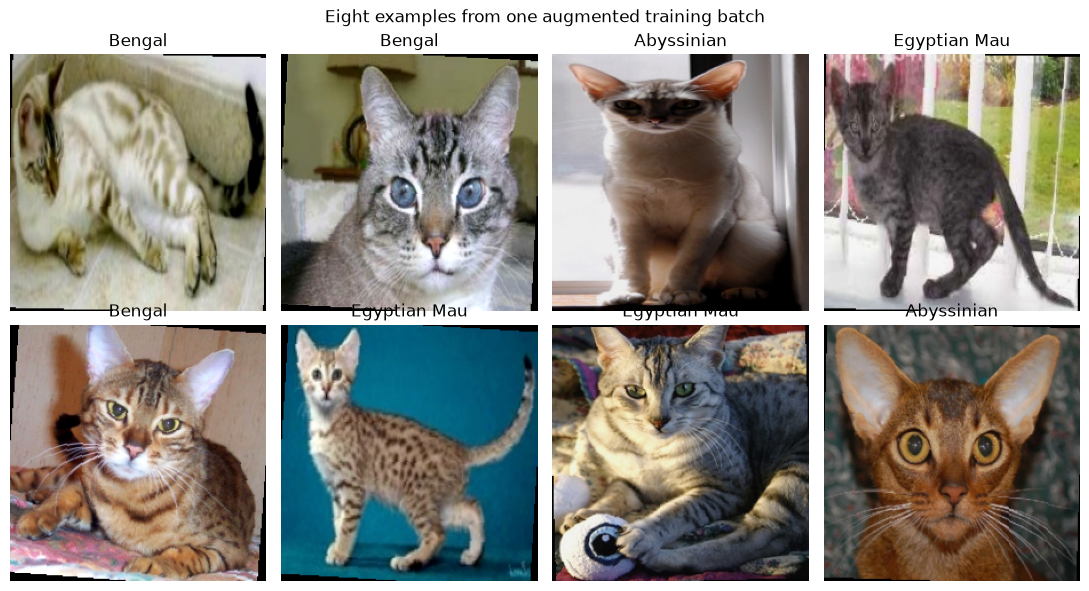

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for axis, image_tensor, label_id in zip(axes.flat, image_batch[:8], label_batch[:8]):
    axis.imshow(tensor_for_display(image_tensor))
    axis.set_title(SELECTED_CLASSES[int(label_id)])
    axis.axis("off")
plt.suptitle("Eight examples from one augmented training batch")
plt.tight_layout()
plt.show()

## Checkpoint before Notebook 3

The pipeline is now: source image + mask → box → crop → transform → tensor → batch.

Answer these from memory:

1. Why is random augmentation used for training but not validation or test?
2. In [16, 3, 224, 224], what does each number mean?
3. What is the difference between a Dataset and a DataLoader?
4. Does creating deterministic test crops mean we used test results to tune the model? Why?
5. Why can a rectangular crop still contain some background?

Save after all cells run successfully. Notebook 3 will inspect a small CNN and a pretrained ResNet18 before training.